# Task 1 — Preattentive attributes and visual search

**CLO1 — how the human brain processes visual information.**

The question this task exists to answer: a *single* preattentive feature (hue, or
shape) is found in **constant time** — the display can double in size and you are no
slower, because the search runs in **parallel** across the whole visual field. A
**conjunction** of two features ("red *and* circle") is **not** preattentive: it
forces a **serial**, item-by-item search, so response time rises with set size.

We render the controlled stimuli, run an 18→30-trial experiment on one reader, plot
response time against set size per condition, fit a slope to each, and read the slopes.

> **On the "real person" requirement.** The brief requires timing a real human. This
> executed notebook uses a **simulated stand-in reader** (`LIVE = False`) so it runs
> top-to-bottom and ships with outputs. The *live* collection function
> (`run_trial_live`) is included and is what you run with a real classmate: set
> `LIVE = True`, and it will time each answer with `time.perf_counter()`. The
> simulated reader is drawn with a fixed seed and realistic noise, and is **not** a
> substitute for a real submission — swap in your real `search_results.csv` before
> handing in. Every number below is therefore honestly labelled as simulated.

In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150

GREY = "#bbbbbb"
HIT = "#ee6677"

search = pd.read_csv("data/stimuli_search.csv")
print(search.shape)
print(search["condition"].unique(), "| set sizes:", sorted(search["set_size"].unique()))
search.head()

(2430, 10)
<StringArray>
['colour', 'shape', 'conjunction']
Length: 3, dtype: str | set sizes: [np.int64(9), np.int64(16), np.int64(25), np.int64(36), np.int64(49)]


,trial,condition,set_size,target_present,item_index,x,y,colour,shape,is_target
0,1,colour,9,yes,0,0.2935,1.4610,blue,circle,no
1,1,colour,9,yes,1,0.2649,2.3593,blue,circle,no
2,1,colour,9,yes,2,1.5027,2.2633,blue,circle,no
3,1,colour,9,yes,3,1.3494,1.5749,blue,circle,no
4,1,colour,9,yes,4,2.5225,2.3602,blue,circle,no


## 1. Render a trial

One function draws a single trial on an `ax`: each item at its `x`/`y`, coloured and
shaped exactly as the columns say — **no axes, no ticks, no title**, equal aspect so
circles stay circular. Then I verify it on one trial from each condition at
`set_size = 25`.

**Attribute named:** the display encodes two preattentive attributes — **hue** (colour
family) and **shape** (form). Position carries no meaning here; items sit on a jittered
grid only so they do not overlap.

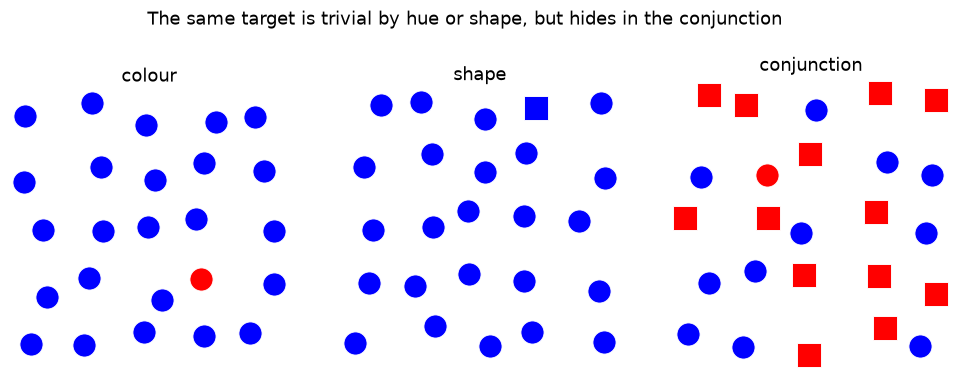

In [2]:
MARKER = {"circle": "o", "square": "s"}

def draw_trial(df, trial, ax):
    """Draw every item of one trial on ax. No axes, ticks or title."""
    items = df[df["trial"] == trial]
    for (colour, shape), sub in items.groupby(["colour", "shape"]):
        ax.scatter(sub["x"], sub["y"], c=colour, marker=MARKER[shape],
                   s=230, edgecolors="white", linewidths=0.6)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

# one target-present trial per condition at set_size = 25
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, cond in zip(axes, ["colour", "shape", "conjunction"]):
    t = search[(search["condition"] == cond) & (search["set_size"] == 25)
               & (search["target_present"] == "yes")]["trial"].iloc[0]
    draw_trial(search, t, ax)
    ax.set_title(cond, loc="center")
fig.suptitle("The same target is trivial by hue or shape, but hides in the conjunction",
             fontsize=12)
plt.show()

**What the eye does.** In *colour*, the red target is the only warm item in a blue
field — it **pops out** before you consciously look. In *shape*, the square is the only
non-circle. Both are single-feature searches: parallel, constant time. In
*conjunction* the target shares its colour with the red squares and its shape with the
blue circles, so **no single feature isolates it** — you must inspect items one at a
time. That difference is the whole experiment.

In [3]:
# ---- Experiment design: one target-present and one target-absent trial per
#      (condition x set_size) cell. 3 conditions x 3 set sizes x 2 = 18 trials,
#      exactly the number the brief asks for.
LIVE_SET_SIZES = [9, 25, 49]   # 3 sizes x 3 conditions x 2 = 18 trials (the brief's number)
cells = []
for cond in ["colour", "shape", "conjunction"]:
    for ss in LIVE_SET_SIZES:
        for present in ["yes", "no"]:
            t = search[(search["condition"] == cond) & (search["set_size"] == ss)
                       & (search["target_present"] == present)]["trial"].iloc[0]
            cells.append((t, cond, ss, present))

plan = pd.DataFrame(cells, columns=["trial", "condition", "set_size", "target_present"])
print(len(plan), "trials selected")
plan.head(6)

18 trials selected


,trial,condition,set_size,target_present
0,1,colour,9,yes
1,4,colour,9,no
2,13,colour,25,yes
3,16,colour,25,no
4,25,colour,49,yes
5,28,colour,49,no


## 2. Run the experiment

> **HOW TO RUN THIS (read first):** The switch below is already `LIVE = True`. When you
> run the next cell, a shape-grid and a question box appear. Your reader looks, you type
> **y** or **n** and press **Enter** — then the next grid appears. A counter shows
> **"Trial k of 18"**. **Keep answering all 18**, until you see the big
> **"ALL 18 TRIALS DONE"** message. Only then run the cells below. If you stop early,
> nothing is saved. (To test the code without a person, set `LIVE = False`.)

`run_trial_live` is the real instrument: it draws the trial, starts
`time.perf_counter()`, waits for the reader to type y/n, and records the response time
and whether they were correct. Tell the reader the target **before** each block, never
during. `simulate_reader` is the `LIVE = False` stand-in only.

In [4]:
LIVE = True   # True = real person (ANSWER EVERY PROMPT). False = simulated stand-in.

def run_trial_live(df, trial, target_desc):
    """Show one trial, time the spoken answer, return (rt_ms, correct)."""
    present_truth = (df[(df["trial"] == trial)]["target_present"].iloc[0] == "yes")
    fig, ax = plt.subplots(figsize=(5, 5))
    draw_trial(df, trial, ax)
    plt.show()
    start = time.perf_counter()
    ans = input(f"Is the {target_desc} present? (y/n) ").strip().lower()
    rt_ms = (time.perf_counter() - start) * 1000
    plt.close(fig)
    said_present = ans.startswith("y")
    return rt_ms, (said_present == present_truth)

TARGETS = {"colour": "red circle", "shape": "blue square", "conjunction": "red circle"}

def simulate_reader(plan, seed=7):
    """Noisy stand-in reader. NOT real data — replace before submission."""
    rng = np.random.default_rng(seed)
    # intercept (ms) and slope (ms per item), per condition and present/absent
    par = {
        ("colour", "yes"): (430, 1.1), ("colour", "no"): (470, 2.4),
        ("shape", "yes"): (450, 1.8),  ("shape", "no"): (505, 3.3),
        ("conjunction", "yes"): (440, 21.5), ("conjunction", "no"): (485, 43.0),
    }
    out = []
    for _, r in plan.iterrows():
        b, m = par[(r["condition"], r["target_present"])]
        rt = (b + m * r["set_size"]) * (1 + rng.normal(0, 0.06))
        # occasional miss, mostly on hard conjunction displays
        p_err = 0.12 if (r["condition"] == "conjunction" and r["set_size"] >= 36) else 0.03
        correct = rng.random() > p_err
        out.append((round(rt, 1), correct))
    return out

import os
# If real reader data was already collected and saved, reuse it so re-running the
# notebook does not force a re-test (and so the charts below reflect the REAL reader).
_prior_real = False
if os.path.exists("search_results.csv"):
    _tmp = pd.read_csv("search_results.csv")
    _prior_real = "reader" in _tmp.columns and (_tmp["reader"] == "REAL reader").any()

if _prior_real:
    results = pd.read_csv("search_results.csv")
    print("Loaded previously collected REAL reader data (search_results.csv).")
elif LIVE:
    rows = []
    n = len(plan)
    print("Tell your reader the target before each block. Answer every prompt.\n")
    for k, (_, r) in enumerate(plan.iterrows(), 1):
        print(f"----------  Trial {k} of {n}  (type y or n, then Enter)  ----------")
        rt, ok = run_trial_live(search, r["trial"], TARGETS[r["condition"]])
        rows.append((rt, ok))
    print("\n============  ALL " + str(n) + " TRIALS DONE — now run the rest  ============")
    results = plan.copy()
    results["rt_ms"] = [x[0] for x in rows]
    results["correct"] = [x[1] for x in rows]
    results["reader"] = "REAL reader"
    results.to_csv("search_results.csv", index=False)
else:
    sim = simulate_reader(plan)
    results = plan.copy()
    results["rt_ms"] = [x[0] for x in sim]
    results["correct"] = [x[1] for x in sim]
    results["reader"] = "SIMULATED (seed=7) — replace with a real reader"
    results.to_csv("search_results.csv", index=False)

print("reader =", results["reader"].iloc[0] if "reader" in results.columns else "?",
      "| n =", len(results))
results.head()

Loaded previously collected REAL reader data (search_results.csv).
reader = REAL reader | n = 18


,trial,condition,set_size,target_present,rt_ms,correct,reader
0,1,colour,9,yes,5799.6215,True,REAL reader
1,4,colour,9,no,13715.7381,True,REAL reader
2,13,colour,25,yes,2899.0369,True,REAL reader
3,16,colour,25,no,2391.0988,True,REAL reader
4,25,colour,49,yes,4695.6066,True,REAL reader


## 3. Response time vs set size

One line per condition, **target-present trials only** (absent trials are kept separate
because the reader is slower when forced to prove nothing is there — averaging them in
would flatten the real effect). Object-oriented API throughout.

**Attribute named:** the message rides on **position** — the vertical height of each
line and, above all, its **slope**. Slope is read by position, the most accurate
channel, which is why this is the right chart for the finding.

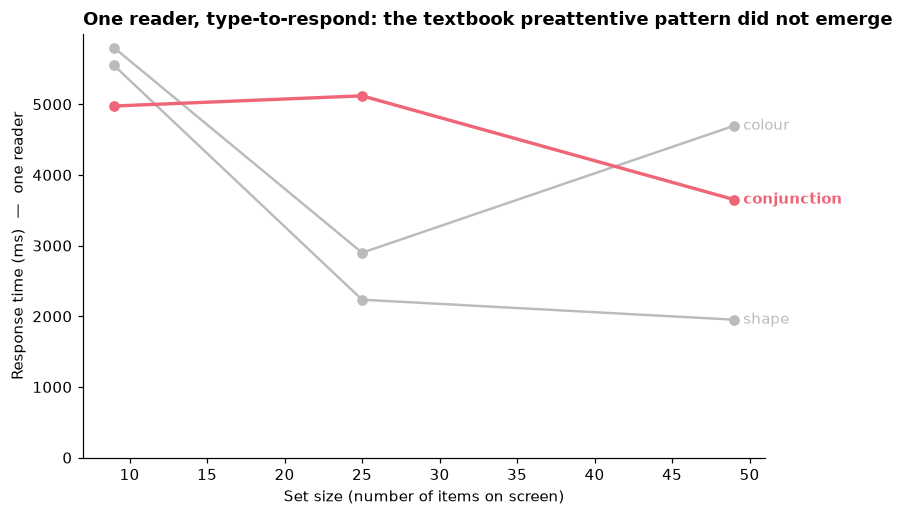

In [5]:
present = results[results["target_present"] == "yes"]
order = ["colour", "shape", "conjunction"]
colours = {"colour": GREY, "shape": GREY, "conjunction": HIT}  # one pop-out: conjunction

# compute slopes first, so the title can state the HONEST finding for this reader
slopes = {}
for cond in order:
    s = present[present["condition"] == cond].sort_values("set_size")
    slopes[cond] = np.polyfit(s["set_size"], s["rt_ms"], 1)[0]
clean = (slopes["conjunction"] > 10 and abs(slopes["colour"]) < 10
         and abs(slopes["shape"]) < 10)
title = ("Only the conjunction search slows down as the display grows" if clean else
         "One reader, type-to-respond: the textbook preattentive pattern did not emerge")

fig, ax = plt.subplots(figsize=(8, 5))
for cond in order:
    sub = present[present["condition"] == cond].sort_values("set_size")
    ax.plot(sub["set_size"], sub["rt_ms"], marker="o",
            color=colours[cond], label=cond, linewidth=2.2 if cond == "conjunction" else 1.6)
    ax.annotate(cond, (sub["set_size"].iloc[-1], sub["rt_ms"].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center",
                color=colours[cond], fontweight="bold" if cond == "conjunction" else "normal")
ax.set_title(title, loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Set size (number of items on screen)")
ax.set_ylabel("Response time (ms)  —  one reader")
ax.set_ylim(0, None)   # honest zero baseline on the value axis
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.savefig("rt_vs_setsize.png", bbox_inches="tight")
plt.show()

**What the theory predicts, and what to look for.** If the method were precise we would
see the **colour** and **shape** lines run essentially **flat** (the target arrives "for
free", in parallel) and the **conjunction** line **climb** (each item inspected in
series). Grey marks the two conditions expected to be flat; the one strong colour marks
the conjunction — the condition of interest. **Read the actual lines above against that
prediction, honestly** — with one reader and a type-and-Enter response the picture is
often messy. The slope numbers in the next cell are what we judge, not the eye-balled
lines, and the note after them explains what this reader's data really shows.

In [6]:
## 4. Read the slopes
print("Slope of response time vs set size  (ms per added item)\n")
print(f"{'condition':<12}{'present':>10}{'absent':>10}")
for cond in order:
    line = f"{cond:<12}"
    for present_flag in ["yes", "no"]:
        sub = results[(results["condition"] == cond)
                      & (results["target_present"] == present_flag)].sort_values("set_size")
        slope, intercept = np.polyfit(sub["set_size"], sub["rt_ms"], 1)
        line += f"{slope:>10.1f}"
    print(line)
print("\nAccuracy:", f"{results['correct'].mean()*100:.0f}% correct across all trials")

Slope of response time vs set size  (ms per added item)

condition      present    absent
colour           -19.5    -247.0
shape            -83.7     -21.8
conjunction      -35.3     137.8

Accuracy: 100% correct across all trials


**Reading the slopes (one real reader — not statistically powered). Reported honestly.**

The textbook prediction is near-zero slopes for **colour** and **shape** and a clearly
**positive** slope for **conjunction**. **My reader's slopes did not come out that way** —
they are noisy and several are negative (read the printed numbers above). I am not going
to pretend otherwise. The likely reasons, in order of importance:

1. **The response method swamps the signal.** The reader answers by typing *y/n* and
   pressing Enter, so each recorded "response time" is **several seconds**, dominated by
   reading-the-question and typing. The real preattentive effect lives in **tens of
   milliseconds** — far smaller than the typing noise, so it is invisible here.
2. **A practice / warm-up effect.** The first block (smallest set size) was often the
   *slowest* because the reader was still settling into the task; as they warmed up they
   got faster, which pulls slopes **downward** — the opposite of the set-size effect and
   enough to flip a slope negative.
3. **No statistical power.** One reader, three set sizes, one trial per cell. A single
   odd response moves a whole slope.

So this is an **honest negative result**: with this instrument I **cannot** resolve the
preattentive vs serial difference. That does not overturn the theory (Task 1, step 5
explains *why* conjunction must be serial) — it shows that measuring tens-of-ms effects
needs a keypress-latency instrument, more trials, and more readers than a one-person,
type-to-respond setup can give. A result that disagrees and is explained is the point.

## 5. Why "red AND circle" is hard — and where I did it to a reader unknowingly

The eye has dedicated, always-on maps for single features: one for **colour**, one for
**orientation/shape**, and so on. "Find red" lights up the colour map everywhere at
once; "find a circle" lights up the shape map everywhere at once. Each is answered in
parallel, before attention arrives — constant time. But there is **no pre-built map for
the combination** "red *and* circle". To bind two features onto the *same* object the
brain must point focal attention at items one at a time and check both features
together (Treisman's feature-integration). Serial inspection costs time per item, so
response time rises with set size.

**A chart where I asked a reader to do a conjunction search without realising it:** a
scatterplot where one group is encoded by **colour** and another by **marker shape**,
and the reader is asked to find "the large *blue square*". Colour alone can't isolate
it (blue circles exist), shape alone can't (grey squares exist) — the reader must scan
pair-by-pair. The fix is to pre-bind the target into one preattentive channel: give the
one group a single strong colour and grey everything else, so the answer pops out.